In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

In [2]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [3]:
import os

for root, dirs, files in os.walk('/'):
    if 'onboarding_ml.csv' in files:
        print(os.path.join(root, 'onboarding_ml.csv'))

In [6]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [7]:
from google.colab import files

uploaded = files.upload()

Saving onboarding_ml.csv to onboarding_ml.csv


In [10]:
df = pd.read_csv('onboarding_ml.csv')
print(df.shape)

(1194, 16)


In [12]:
df.columns.tolist()

['id_evento',
 'numero_caso',
 'cliente_id',
 'etapa_id',
 'canal_id',
 'tipo_verificacion',
 'estado_documentacion',
 'aml_risk_score',
 'fecha_inicio',
 'fecha_fin',
 'tiempo_horas',
 'estado_evento',
 'risk_id',
 'fecha_id',
 'id_evento;numero_caso;cliente_id;etapa_id;canal_id;tipo_verific',
 'risk_score']

In [13]:
df[['estado_evento','risk_score','tipo_verificacion','estado_documentacion']].head()

,estado_evento,risk_score,tipo_verificacion,estado_documentacion
0,Approved,12,Manual,Complete
1,Approved,28,Manual,Complete
2,Approved,0,Manual,Complete
3,Approved,1,Manual,Complete
4,Approved,38,Manual,Complete


In [14]:
df['estado_evento'].value_counts()

,count
estado_evento,
Approved,1075
Rejected,119


In [15]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

le_verification = LabelEncoder()
le_docs = LabelEncoder()
le_target = LabelEncoder()

df_ml['tipo_verificacion'] = le_verification.fit_transform(df_ml['tipo_verificacion'])
df_ml['estado_documentacion'] = le_docs.fit_transform(df_ml['estado_documentacion'])
df_ml['estado_evento'] = le_target.fit_transform(df_ml['estado_evento'])

df_ml.head()

,id_evento,numero_caso,cliente_id,etapa_id,canal_id,tipo_verificacion,estado_documentacion,aml_risk_score,fecha_inicio,fecha_fin,tiempo_horas,estado_evento,risk_id,fecha_id,id_evento;numero_caso;cliente_id;etapa_id;canal_id;tipo_verific,risk_score
0,1004,251,251,6,1,1,0,False,2026-01-05 23:00:00.000,2026-02-05 17:00:00.000,738.0,0,1,20260501,NaN,12
1,1003,251,251,4,1,1,0,False,2026-01-05 15:00:00.000,2026-01-06 11:00:00.000,20.0,0,2,20260501,NaN,28
2,1002,251,251,2,1,1,0,False,2026-01-05 05:00:00.000,2026-01-06 03:00:00.000,22.0,0,1,20260501,NaN,0
3,1001,251,251,1,1,1,0,False,2026-01-05 00:00:00.000,2026-01-05 17:00:00.000,17.0,0,1,20260501,NaN,1
4,765,192,192,1,3,1,0,False,2026-02-06 00:00:00.000,2026-02-06 17:00:00.000,17.0,0,2,20260602,NaN,38


In [16]:
X = df_ml[['risk_score',
           'tipo_verificacion',
           'estado_documentacion']]

y = df_ml['estado_evento']

print(X.head())

   risk_score  tipo_verificacion  estado_documentacion
0          12                  1                     0
1          28                  1                     0
2           0                  1                     0
3           1                  1                     0
4          38                  1                     0


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(955, 3)
(239, 3)


In [19]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9121338912133892


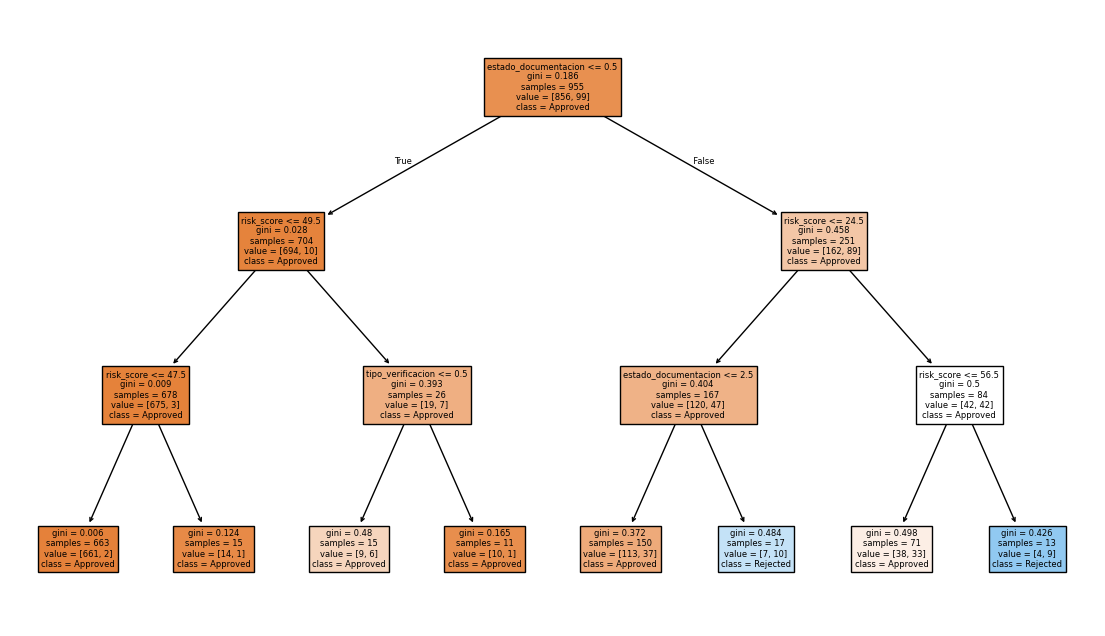

In [21]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Approved','Rejected'],
    filled=True
)

plt.show()

In [22]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9121338912133892
